In [ ]:
!pip install numpy==2.1.3




In [ ]:
import numpy as np
print(np.__version__)

In [ ]:
import pandas as pd
print(pd.__version__)

In [ ]:
import sys, numpy as np
print(sys.executable)  # Check Python path
print(np.__version__)  # Check loaded NumPy version
print(np.__file__)     # Check NumPy installation path


In [ ]:
import pandas as pd
print(pd.__version__)

In [ ]:
import importlib
import numpy as np
print(np.__version__)


In [1]:
import pandas as pd
merged_df_new = pd.read_pickle("/kaggle/input/capstone-image-data/merged_df_new.pkl")

2025-04-30 22:09:30.865624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746050970.888284     745 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746050970.895034     745 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1746050974.299764     745 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
merged_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6918 entries, 0 to 6917
Data columns (total 57 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   event_type                              6918 non-null   object 
 1   begin_date_time                         6918 non-null   object 
 2   cz_timezone                             6918 non-null   object 
 3   end_date_time                           6918 non-null   object 
 4   begin_lat                               6918 non-null   float64
 5   begin_lon                               6918 non-null   float64
 6   end_lat                                 6918 non-null   float64
 7   end_lon                                 6918 non-null   float64
 8   extreme                                 6918 non-null   int64  
 9   begin_date_utc                          6918 non-null   object 
 10  begin_time_utc                          6918 non-null   obje

In [ ]:
import pandas as pd
import os
from tqdm import tqdm
# List of all your pickle file paths
file_paths = [
    "/kaggle/input/capstone-data-with-all-images/df_with_images/merged_df_checkpoint_12of18.pkl",
    "/kaggle/input/capstone-data-with-all-images/df_with_images/merged_df_checkpoint_16of18.pkl",
    "/kaggle/input/capstone-data-with-all-images/df_with_images/merged_df_checkpoint_18of18.pkl",
    "/kaggle/input/capstone-data-with-all-images/df_with_images/merged_df_checkpoint_4of18.pkl",
    "/kaggle/input/capstone-data-with-all-images/df_with_images/merged_df_checkpoint_8of18.pkl"
]

# Read and concatenate all DataFrames
all_dfs = [pd.read_pickle(path) for path in tqdm(file_paths)]
combined_df = pd.concat(all_dfs, ignore_index=True)

# Verify
print(combined_df.shape)


In [3]:
meteo_cols =['prev_72h_temperature_2m',
 'prev_72h_relative_humidity_2m',
 'prev_72h_dew_point_2m',
 'prev_72h_apparent_temperature',
 'prev_72h_precipitation',
 'prev_72h_rain',
 'prev_72h_pressure_msl',
 'prev_72h_surface_pressure',
 'prev_72h_cloud_cover',
 'prev_72h_cloud_cover_low',
 'prev_72h_cloud_cover_mid',
 'prev_72h_cloud_cover_high',
 'prev_72h_et0_fao_evapotranspiration',
 'prev_72h_vapour_pressure_deficit',
 'prev_72h_wind_speed_10m',
 'prev_72h_wind_speed_100m',
 'prev_72h_wind_direction_10m',
 'prev_72h_wind_direction_100m',
 'prev_72h_wind_gusts_10m',
 'prev_72h_soil_temperature_0_to_7cm',
 'prev_72h_soil_temperature_7_to_28cm',
 'prev_72h_soil_temperature_28_to_100cm',
 'prev_72h_soil_temperature_100_to_255cm',
 'prev_72h_soil_moisture_0_to_7cm',
 'prev_72h_soil_moisture_7_to_28cm',
 'prev_72h_soil_moisture_28_to_100cm',
 'prev_72h_soil_moisture_100_to_255cm']

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset

X_train_metadata = X_train[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_test_metadata = X_test[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_validation_metadata = X_validation[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()

X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, 
                                     Bidirectional, LSTM, Attention, GlobalAveragePooling1D, concatenate, 
                                     Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, TimeDistributed, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime
from tensorflow.keras.regularizers import l2
# ---------------------------
# Utility Functions for Preprocessing
# ---------------------------




# ---------------------------
# Model Definition
# ---------------------------

# Weather Data Branch
weather_input = Input(shape=(72, 27), name='weather_input')
w = Conv1D(filters=64, kernel_size=3, padding='same', kernel_regularizer=l2)(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)
w = Conv1D(filters=128, kernel_size=5, padding='same', kernel_regularizer=l2)(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)
# Residual connection: slice first half of the input, then process it
shortcut = Lambda(lambda x: x[:, :tf.shape(x)[1] // 2, :])(weather_input)
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(shortcut)
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])
w = Conv1D(filters=64, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# Image Data Branch
image_input = Input(shape=(3, 128, 128, 3), name='image_input')
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same',kernel_regularizer=l2))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(GlobalAveragePooling2D())(i)
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)
i = Dropout(0.4)(i)
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# Meta Data Branch (for datetime and location features)
# Here, we have a 6-dimensional input: [sin_hour, cos_hour, sin_month, cos_month, norm_lat, norm_lon]
meta_input = Input(shape=(6,), name='meta_input')
meta_features = Dense(16, activation='relu')(meta_input)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)
meta_features = Dense(8, activation='relu')(meta_features)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)

# Merge all branches
combined_features = concatenate([weather_features, img_features, meta_features], name='combined_features')
x = Dense(64, activation='relu')(combined_features)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

model = Model(inputs=[weather_input, image_input, meta_input], outputs=extreme_output)
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

# Display the model summary
model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 50
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

In [ ]:
nan_count = np.isnan(X_images).sum()

print(f"Number of NaN values: {nan_count}")

In [ ]:
print(type(X_images))
print(X_images.dtype)


In [5]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            print("jhe")
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)


# Create a dataset for the weather input
ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train, ds_metadata_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val, ds_metadata_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test, ds_metadata_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()
ds_val = ds_val.repeat()


In [6]:
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test, ds_metadata_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)


In [7]:
import math

num_samples = len(X_train)  # Replace with the actual number of training samples
batch_size = 64  # Replace with your batch size
num_samples_val = len(X_validation)

steps_per_epoch = math.ceil(num_samples / batch_size)
steps_per_epoc_val = math.ceil(num_samples_val / batch_size)

In [10]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,
    validation_steps=steps_per_epoc_val,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20


I0000 00:00:1746051085.519696     803 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/70 ━━━━━━━━━━━━━━━━━━━━ 37:05 32s/step - accuracy: 0.0000e+00 - loss: 3.0254 - pr_auc: 0.6025 - precision_1: 0.6061 - recall_1: 0.5714 - roc_auc: 0.5414jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 53s 300ms/step - accuracy: 0.0000e+00 - loss: 3.0326 - pr_auc: 0.5132 - precision_1: 0.5132 - recall_1: 0.5147 - roc_auc: 0.5166 - val_accuracy: 0.0000e+00 - val_loss: 2.5340 - val_pr_auc: 0.4940 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - val_roc_auc: 0.4941 - learning_rate: 1.0000e-04
Epoch 2/20
 1/70 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.0000e+00 - loss: 2.9120 - pr_auc: 0.5043 - precision_1: 0.4783 - recall_1: 0.3143 - roc_auc: 0.4458jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.0000e+00 - loss: 2.8042 - pr_auc: 0.5036 - precision_1: 0.4936 - recall_1: 0.4923 - roc_auc: 0.4983 - val_accuracy: 0.0000e+00 - val_loss: 2.3949 - val_pr_auc: 0.5081 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - val_roc_auc: 0.5144 - learning_rate: 1.0000e-04
Epoch 3/20


In [18]:
import pickle

with open("First_model_history.pkl","wb") as f:
    pickle.dump(history_1, f)
history_1.history.items()

dict_items([('accuracy', [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), ('loss', [2.9953877925872803, 2.7427752017974854, 2.52453351020813, 2.334300994873047, 2.1607606410980225, 2.0497772693634033, 1.9237804412841797, 1.8392186164855957, 1.767132043838501, 1.6902704238891602, 1.6212828159332275, 1.5641448497772217, 1.4943552017211914, 1.4398022890090942, 1.4210230112075806, 1.343219518661499, 1.3226147890090942, 1.290978193283081, 1.238877534866333, 1.206475853919983]), ('pr_auc', [0.5119578838348389, 0.5143566727638245, 0.523884654045105, 0.5377283096313477, 0.5608524680137634, 0.5603746175765991, 0.592648983001709, 0.5907943248748779, 0.5943429470062256, 0.6128444671630859, 0.6184271574020386, 0.6201887726783752, 0.642186164855957, 0.651515781879425, 0.6476209163665771, 0.6792182326316833, 0.669139564037323, 0.6736809611320496, 0.6980095505714417, 0.695324718952179]), ('precision_1', [0.5102412104606628, 0.5087476968765259, 0.5

In [19]:
import numpy as np
# import seaborn as sns

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)



# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)




22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step
Test Accuracy: 0.6452
Test Precision: 0.6502
Test Recall: 0.6286
Test F1-Score: 0.6392
Test ROC AUC: 0.6903


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [20]:
print(cm)

[[458 234]
 [257 435]]


## mdoel with 1.1 million

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# # ---------------------------
# # Weather Data Branch
# # ---------------------------
# # For example, assume weather data is a sequence of 100 timesteps with 64 features.
weather_input = Input(shape=(72, 27), name='weather_input')

# Conv Block 1
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)

# Conv Block 2
w = Conv1D(filters=128, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# Residual Connection from Block 1
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(weather_input[:, :weather_input.shape[1]//2, :])
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])

# Conv Block 3
w = Conv1D(filters=128, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# LSTM and Attention
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# ---------------------------
# Image Data Branch (Feature Extraction for Time-Series of Images)
# ---------------------------
# For example, assume each row contains a sequence of 24 images of shape (224, 224, 3)
image_input = Input(shape=(3, 128, 128, 3), name='image_input')  # Input for the sequence of images

# TimeDistributed wrapper to apply CNN to each image in the sequence
from tensorflow.keras.layers import TimeDistributed

# Apply CNN feature extraction to each image in the sequence
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

i = TimeDistributed(Conv2D(128, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)

# Global pooling to reduce each image to a feature vector
i = TimeDistributed(GlobalAveragePooling2D())(i)

# Process the sequence of feature vectors with an LSTM
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)  # Final output for the sequence
i = Dropout(0.4)(i)

# Optional fully connected layer to further process image sequence features
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# ---------------------------
# Merge Branches and Build Final Classification Head
# ---------------------------
# Merge the weather and image features
combined_features = concatenate([weather_features, img_features], name='combined_features')

# Fully connected layers for extreme event classification
x = Dense(64)(combined_features)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

# Define the complete multi-modal model
model = Model(inputs=[weather_input, image_input], outputs=extreme_output)

# Compile the model with Adam optimizer and binary cross-entropy loss
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])
# model = model_build()
# Display the model summary
model.summary()


# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 20
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)  │ (None, 3, 128, 128, 3) │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_32       │ (None, 3, 128, 128,    │            896 │ image_input[0][0]      │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_33       │ (None, 3, 128, 128,    │            128 │ time_distributed_32[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ weather_input             │ (None, 72, 27)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_34       │ (None, 3, 128, 128,    │              0 │ time_distributed_33[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_8 (Conv1D)         │ (None, 72, 64)         │          5,248 │ weather_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_35       │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_34[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_22    │ (None, 72, 64)         │            256 │ conv1d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_36       │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_35[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_12            │ (None, 72, 64)         │              0 │ batch_normalization_2… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_37       │ (None, 3, 64, 64, 64)  │         18,496 │ time_distributed_36[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_2           │ (None, 36, 64)         │              0 │ leaky_re_lu_12[0][0]   │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_38       │ (None, 3, 64, 64, 64)  │            256 │ time_distributed_37[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_28 (Dropout)      │ (None, 36, 64)         │              0 │ max_pooling1d_2[0][0]  │
├──────────────────────

 Total params: 1,149,505 (4.39 MB)

 Trainable params: 1,147,777 (4.38 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
X_images[0]

In [27]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            print("jhe")
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)


# Create a dataset for the weather input
ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()
ds_val = ds_val.repeat()



In [28]:
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)


In [23]:
import math

num_samples = len(X_train)  # Replace with the actual number of training samples
batch_size = 64  # Replace with your batch size
num_samples_val = len(X_validation)

steps_per_epoch = math.ceil(num_samples / batch_size)
steps_per_epoc_val = math.ceil(num_samples_val / batch_size)

In [24]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,
    validation_steps=steps_per_epoc_val,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
 1/70 ━━━━━━━━━━━━━━━━━━━━ 29:59 26s/step - accuracy: 0.0000e+00 - loss: 0.9232 - pr_auc: 0.6461 - precision_2: 0.6923 - recall_2: 0.2571 - roc_auc: 0.5409jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 46s 285ms/step - accuracy: 0.0000e+00 - loss: 0.9133 - pr_auc: 0.5170 - precision_2: 0.5113 - recall_2: 0.2468 - roc_auc: 0.5087 - val_accuracy: 0.0000e+00 - val_loss: 0.7032 - val_pr_auc: 0.5218 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - val_roc_auc: 0.5298 - learning_rate: 1.0000e-04
Epoch 2/20
 2/70 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.0000e+00 - loss: 0.9445 - pr_auc: 0.4873 - precision_2: 0.4044 - recall_2: 0.1825 - roc_auc: 0.4818jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 233ms/step - accuracy: 0.0000e+00 - loss: 0.8694 - pr_auc: 0.5130 - precision_2: 0.4925 - recall_2: 0.2888 - roc_auc: 0.5129 - val_accuracy: 0.0000e+00 - val_loss: 0.6979 - val_pr_auc: 0.5361 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - val_roc_auc: 0.5410 - learning_rate: 1.0000e-04


In [25]:
with open("Second_model_history.pkl", "wb") as f:
    pickle.dump(history_1.history, f)

In [29]:
import numpy as np
# import seaborn as sns

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)



# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)




22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Test Accuracy: 0.6221
Test Precision: 0.6539
Test Recall: 0.5188
Test F1-Score: 0.5786
Test ROC AUC: 0.6805


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


##

## trying new model

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset

X_train_metadata = X_train[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_test_metadata = X_test[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_validation_metadata = X_validation[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()

X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, 
                                     Bidirectional, LSTM, Attention, GlobalAveragePooling1D, concatenate, 
                                     Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, TimeDistributed, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime
from tensorflow.keras.regularizers import l2
# ---------------------------
# Utility Functions for Preprocessing
# ---------------------------



from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ---------------------------
# Custom Vision Transformer Components
# ---------------------------
class ClassToken(Layer):
    """Adds a learnable class token to the patch embeddings"""
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.cls_token = self.add_weight(
            shape=(1, 1, d_model),
            initializer='random_normal',
            trainable=True
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls_tokens = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls_tokens, inputs], axis=1)

def create_vit(input_shape=(128, 128, 3), 
              patch_size=8,
              d_model=128,
              num_heads=4,
              num_layers=2,
              mlp_dim=256):
    """Creates a Vision Transformer model for single image processing"""
    inputs = Input(shape=input_shape)
    
    # Create patches using Conv2D
    x = Conv2D(filters=d_model,
               kernel_size=patch_size,
               strides=patch_size,
               padding='valid')(inputs)
    x = Reshape((-1, d_model))(x)  # (num_patches, d_model)
    
    # Add class token
    x = ClassToken(d_model=d_model)(x)
    
    # Add positional embeddings
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    positions = tf.range(start=0, limit=num_patches + 1, delta=1)
    position_emb = Embedding(input_dim=num_patches + 1, output_dim=d_model)(positions)
    x = x + position_emb
    
    # Transformer encoder layers
    for _ in range(num_layers):
        # Layer normalization 1
        x1 = LayerNormalization(epsilon=1e-6)(x)
        
        # Multi-head attention
        attn_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )(x1, x1)
        
        # Skip connection 1
        x2 = Add()([attn_output, x])
        
        # Layer normalization 2
        x3 = LayerNormalization(epsilon=1e-6)(x2)
        
        # MLP
        mlp_output = Dense(mlp_dim, activation='gelu')(x3)
        mlp_output = Dense(d_model)(mlp_output)
        
        # Skip connection 2
        x = Add()([mlp_output, x3])
    
    # Extract class token as image representation
    features = x[:, 0, :]
    
    return Model(inputs=inputs, outputs=features)

# ---------------------------
# Weather Data Branch (Unchanged)
# ---------------------------
weather_input = Input(shape=(72, 27), name='weather_input')

# Conv Block 1
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)

# Conv Block 2
w = Conv1D(filters=128, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# Residual Connection
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(weather_input[:, :weather_input.shape[1]//2, :])
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])

# Conv Block 3
w = Conv1D(filters=128, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# LSTM and Attention
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# ---------------------------
# Image Data Branch with ViT
# ---------------------------
image_input = Input(shape=(3, 128, 128, 3), name='image_input')

# Create Vision Transformer model
vit_model = create_vit(input_shape=(128, 128, 3))

# Process image sequence through ViT
i = TimeDistributed(vit_model)(image_input)

# Process temporal features
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)
i = Dropout(0.4)(i)

# Final image features
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# ---------------------------
# Model Integration
# ---------------------------
# Merge branches
combined_features = concatenate([weather_features, img_features])

# Classification head
x = Dense(64)(combined_features)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

# Build complete model
model = Model(inputs=[weather_input, image_input], outputs=extreme_output)

# Compile the model
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

model.summary()


# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 50
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ weather_input             │ (None, 72, 27)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_12 (Conv1D)        │ (None, 72, 64)         │          5,248 │ weather_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_31    │ (None, 72, 64)         │            256 │ conv1d_12[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_19            │ (None, 72, 64)         │              0 │ batch_normalization_3… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_3           │ (None, 36, 64)         │              0 │ leaky_re_lu_19[0][0]   │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_40 (Dropout)      │ (None, 36, 64)         │              0 │ max_pooling1d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_13 (Conv1D)        │ (None, 36, 128)        │         41,088 │ dropout_40[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_32    │ (None, 36, 128)        │            512 │ conv1d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_1 (GetItem)      │ (None, 36, 27)         │              0 │ weather_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_20            │ (None, 36, 128)        │              0 │ batch_normalization_3… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_14 (Conv1D)        │ (None, 36, 128)        │          3,584 │ get_item_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_41 (Dropout)      │ (None, 36, 128)        │              0 │ leaky_re_lu_20[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_33    │ (None, 36, 128)        │            512 │ conv1d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 36, 128)        │              0 │ dropout_41[0][0],      │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_15 (Conv1D)        │ (None, 36, 128)        │        114,816 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3

 Total params: 1,345,153 (5.13 MB)

 Trainable params: 1,343,873 (5.13 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [31]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            print("jhe")
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)


# Create a dataset for the weather input
ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()
ds_val = ds_val.repeat()



In [32]:
import math

num_samples = len(X_train)  # Replace with the actual number of training samples
batch_size = 64  # Replace with your batch size
num_samples_val = len(X_validation)

steps_per_epoch = math.ceil(num_samples / batch_size)
steps_per_epoc_val = math.ceil(num_samples_val / batch_size)

In [34]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,
    validation_steps=steps_per_epoc_val,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

KeyboardInterrupt: 

In [ ]:
import numpy as np
# import seaborn as sns

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)



# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)




In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset

X_train_metadata = X_train[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_test_metadata = X_test[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()
X_validation_metadata = X_validation[["sin_hour","cos_hour","sin_month","cos_month", "lat_norm", "lon_norm"]].copy()

X_images = X_train["images_loaded"].values
X_test_images = X_test["images_loaded"].values
X_validation_images = X_validation["images_loaded"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, 
                                     Bidirectional, LSTM, Attention, GlobalAveragePooling1D, concatenate, 
                                     Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, TimeDistributed, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime
from tensorflow.keras.regularizers import l2
# ---------------------------
# Utility Functions for Preprocessing
# ---------------------------



from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
import tensorflow as tf




# ---------------------------
# Model Definition
# ---------------------------
from tensorflow.keras.layers import Layer, MultiHeadAttention, LayerNormalization, Dense, Lambda

class TemporalAttention(Layer):
    """Proper Keras layer implementation of temporal attention"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.attention_dense = Dense(1, activation='tanh')
        
    def call(self, inputs):
        # inputs shape: (batch_size, timesteps, features)
        attention_scores = self.attention_dense(inputs)  # (batch_size, timesteps, 1)
        attention_weights = tf.nn.softmax(attention_scores, axis=1)
        context_vector = tf.reduce_sum(attention_weights * inputs, axis=1)
        return context_vector

# Modified weather branch with proper layer definitions
weather_input = Input(shape=(72, 27), name='weather_input')

# Conv Block 1
w = Conv1D(64, 3, padding='same', kernel_regularizer=l2(0.01))(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(0.01)(w)
w = MaxPooling1D(2)(w)
w = Dropout(0.3)(w)

# Conv Block 2
w = Conv1D(128, 5, padding='same', kernel_regularizer=l2(0.01))(w)
w = BatchNormalization()(w)
w = LeakyReLU(0.01)(w)
w = Dropout(0.3)(w)

# Residual Connection
shortcut = Lambda(lambda x: x[:, :tf.shape(x)[1]//2, :])(weather_input)
shortcut = Conv1D(128, 1, padding='same')(shortcut)
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])

# Conv Block 3 
w = Conv1D(256, 7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(0.01)(w)
w = Dropout(0.3)(w)

# Temporal Processing
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)

# Use custom TemporalAttention layer instead of Lambda
weather_features = TemporalAttention()(w)


# Image Data Branch
image_input = Input(shape=(3, 128, 128, 3), name='image_input')
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same',kernel_regularizer=l2))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.3))(i)
i = TimeDistributed(GlobalAveragePooling2D())(i)
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.4)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)
i = Dropout(0.4)(i)
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# Meta Data Branch (for datetime and location features)
# Here, we have a 6-dimensional input: [sin_hour, cos_hour, sin_month, cos_month, norm_lat, norm_lon]
meta_input = Input(shape=(6,), name='meta_input')
meta_features = Dense(16, activation='relu')(meta_input)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)
meta_features = Dense(8, activation='relu')(meta_features)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)

# Merge all branches
combined_features = concatenate([weather_features, img_features, meta_features], name='combined_features')
x = Dense(64, activation='relu')(combined_features)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

model = Model(inputs=[weather_input, image_input, meta_input], outputs=extreme_output)
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

# Display the model summary
model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 20
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)  │ (None, 3, 128, 128, 3) │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_49       │ (None, 3, 128, 128,    │            896 │ image_input[0][0]      │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_50       │ (None, 3, 128, 128,    │            128 │ time_distributed_49[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_51       │ (None, 3, 128, 128,    │              0 │ time_distributed_50[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ weather_input             │ (None, 72, 27)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_52       │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_51[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_16 (Conv1D)        │ (None, 72, 64)         │          5,248 │ weather_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_53       │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_52[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_37    │ (None, 72, 64)         │            256 │ conv1d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_54       │ (None, 3, 64, 64, 32)  │          9,248 │ time_distributed_53[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_23            │ (None, 72, 64)         │              0 │ batch_normalization_3… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_55       │ (None, 3, 64, 64, 32)  │            128 │ time_distributed_54[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_4           │ (None, 36, 64)         │              0 │ leaky_re_lu_23[0][0]   │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_56       │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_55[0… │
│ (TimeDistributed)    

 Total params: 1,266,362 (4.83 MB)

 Trainable params: 1,264,522 (4.82 MB)

 Non-trainable params: 1,840 (7.19 KB)

In [36]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            print("jhe")
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)


# Create a dataset for the weather input
ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train, ds_metadata_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val, ds_metadata_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test,ds_metadata_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()



In [37]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,

    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
 1/70 ━━━━━━━━━━━━━━━━━━━━ 33:11 29s/step - accuracy: 0.0000e+00 - loss: 2.9671 - pr_auc: 0.5866 - precision_4: 0.5526 - recall_4: 0.6000 - roc_auc: 0.5044jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 45s 239ms/step - accuracy: 0.0000e+00 - loss: 2.9961 - pr_auc: 0.4938 - precision_4: 0.4920 - recall_4: 0.5069 - roc_auc: 0.4949 - val_accuracy: 0.0000e+00 - val_loss: 2.5167 - val_pr_auc: 0.5021 - val_precision_4: 0.5000 - val_recall_4: 0.0018 - val_roc_auc: 0.5063 - learning_rate: 1.0000e-04
Epoch 2/20


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


 2/70 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.0000e+00 - loss: 2.8155 - pr_auc: 0.4918 - precision_4: 0.5291 - recall_4: 0.4730 - roc_auc: 0.4876jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.0000e+00 - loss: 2.7106 - pr_auc: 0.5199 - precision_4: 0.5082 - recall_4: 0.5097 - roc_auc: 0.5162 - val_accuracy: 0.0000e+00 - val_loss: 2.3242 - val_pr_auc: 0.5300 - val_precision_4: 0.5965 - val_recall_4: 0.0615 - val_roc_auc: 0.5287 - learning_rate: 1.0000e-04
Epoch 3/20
 2/70 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.0000e+00 - loss: 2.6088 - pr_auc: 0.5645 - precision_4: 0.5169 - recall_4: 0.5476 - roc_auc: 0.5332jhe
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.0000e+00 - loss: 2.5127 - pr_auc: 0.5317 - precision_4: 0.5171 - recall_4: 0.5215 - roc_auc: 0.5383 - val_accuracy: 0.0000e+00 - val_loss: 2.1583 - val_pr_auc: 0.5772 - val_precision_4: 0.5114 - val_recall_4: 0.8499 - val_roc_auc: 0.5613 - learning_rate: 1.0000e-04
Epoch 4/20
 2/70 ━━━━━━━━━━

In [38]:
import numpy as np
# import seaborn as sns

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)



# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)




22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step
Test Accuracy: 0.6264
Test Precision: 0.5980
Test Recall: 0.7717
Test F1-Score: 0.6738
Test ROC AUC: 0.6908


In [39]:
# Save
with open("Thirsd_model_history.pkl", "wb") as f:
    pickle.dump(history_1.history, f)



In [41]:
model.save("third_model.h5")

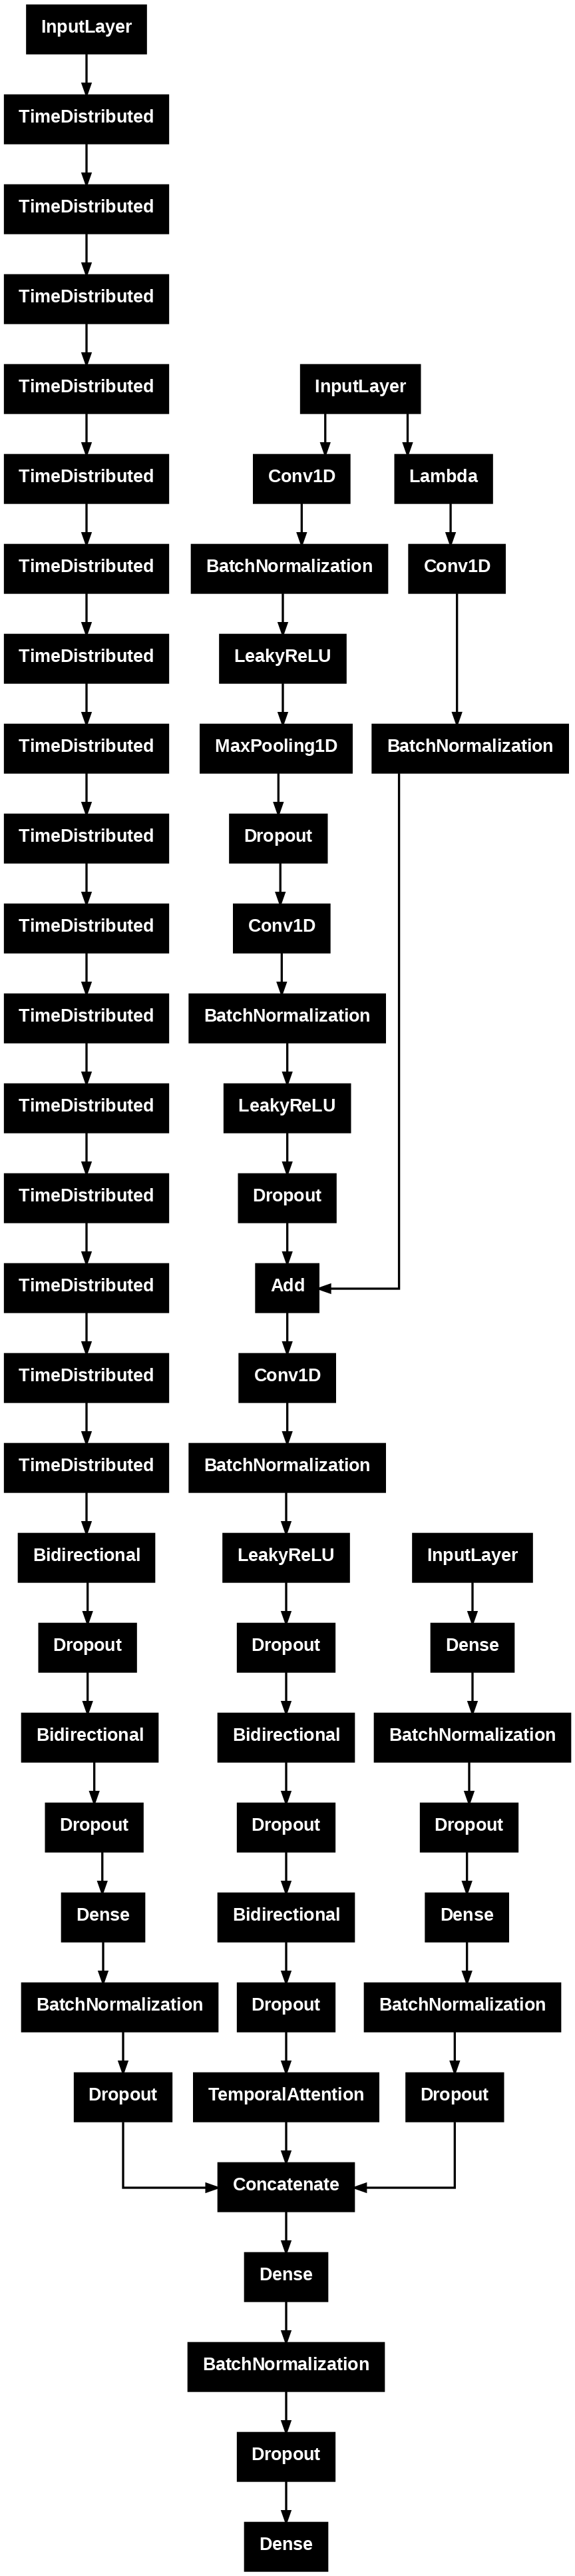

In [40]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model_summary_clean.png",
    show_shapes=False,       # Hide shapes
    show_layer_names=False,  # Hide layer names
    expand_nested=True,      # Expand nested models if any
    dpi=120
)


In [ ]:
%pip install --force-reinstall scikit-learn

In [ ]:
merged_df_new.columns

In [42]:
merged_df_new["images_loaded"].iloc[0].shape

TensorShape([3, 128, 128, 3])

In [43]:
import pandas as pd
import tensorflow as tf
import numpy as np # Needed for sample data generation

from tqdm import tqdm

tqdm.pandas()
# --- 2. Define the Normalization Function ---
def normalize_image_tensor(tensor):
    """
    Normalizes a single image tensor (sequence) to the [0, 1] range.
    Assumes input tensor pixels are in the 0-255 range.
    """
    # Ensure the tensor is float32 type for division
    tensor = tf.cast(tensor, tf.float32)
    # Divide by 255.0 to scale to [0, 1]
    normalized_tensor = tensor / 255.0
    return normalized_tensor

# --- 3. Apply the Normalization ---
# Option A: Create a new column for normalized data (Recommended)
column_name = 'images_loaded' # The column with your image tensors
normalized_column_name = 'normalized_image_data'

merged_df_new[normalized_column_name] = merged_df_new[column_name].progress_apply(normalize_image_tensor)



100%|██████████| 6918/6918 [00:00<00:00, 9492.41it/s]


In [ ]:
%pip install tensorflow_addons

In [ ]:
merged_df_new.shape

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df_new["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df_new["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df_new, y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset


X_images = X_train["normalized_image_data"].values
X_test_images = X_test["normalized_image_data"].values
X_validation_images = X_validation["normalized_image_data"].values


X_train = np.stack(X_train[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_train_bin)/len(y_train_bin))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_train_bin.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_train_bin))
# Scale the y_train_bin
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_train.shape)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_bin.shape)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Example: y_train_bin is your 1D array or list of class labels
classes = np.unique(y_train_bin)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_bin)

# To get a dictionary mapping class label to weight:
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)
# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, 
                                     Bidirectional, LSTM, Attention, GlobalAveragePooling1D, concatenate, 
                                     Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, TimeDistributed, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime
from tensorflow.keras.regularizers import l2
# ---------------------------
# Utility Functions for Preprocessing
# ---------------------------




# ---------------------------
# Model Definition
# ---------------------------

# Weather Data Branch
weather_input = Input(shape=(72, 27), name='weather_input')
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.2)(w)
w = Conv1D(filters=32, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.2)(w)
# Residual connection: slice first half of the input, then process it
shortcut = Lambda(lambda x: x[:, :tf.shape(x)[1] // 2, :])(weather_input)
shortcut = Conv1D(filters=32, kernel_size=1, padding='same')(shortcut)
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])
w = Conv1D(filters=32, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.2)(w)
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.3)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.3)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# Image Data Branch
image_input = Input(shape=(3, 128, 128, 3), name='image_input')
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(image_input)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.1))(i)
i = TimeDistributed(Conv2D(32, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.1))(i)
i = TimeDistributed(Conv2D(64, kernel_size=(3, 3), padding='same'))(i)
i = TimeDistributed(BatchNormalization())(i)
i = TimeDistributed(LeakyReLU(alpha=0.01))(i)
i = TimeDistributed(MaxPooling2D(pool_size=(2, 2)))(i)
i = TimeDistributed(Dropout(0.1))(i)
i = TimeDistributed(GlobalAveragePooling2D())(i)
i = Bidirectional(LSTM(128, return_sequences=True))(i)
i = Dropout(0.3)(i)
i = Bidirectional(LSTM(64, return_sequences=False))(i)
i = Dropout(0.3)(i)
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.3)(img_features)

# Meta Data Branch (for datetime and location features)
# Here, we have a 6-dimensional input: [sin_hour, cos_hour, sin_month, cos_month, norm_lat, norm_lon]
meta_input = Input(shape=(6,), name='meta_input')
meta_features = Dense(16, activation='relu')(meta_input)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)
meta_features = Dense(8, activation='relu')(meta_features)
meta_features = BatchNormalization()(meta_features)
meta_features = Dropout(0.3)(meta_features)

# Merge all branches
combined_features = concatenate([weather_features, img_features], name='combined_features')
x = Dense(64, activation='relu')(combined_features)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

model = Model(inputs=[weather_input, image_input, meta_input], outputs=extreme_output)
optimizer = Adam(learning_rate=2e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

# Display the model summary
model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


# --- Train the Model ---
epochs = 20
batch_size = 32






peecentage of positice instance in training data:  0.5001129433024621
percentage of positice instance in test data:  0.5
percentage of positice instance in validation data:  0.4995483288166215
y resampled shape: (4427,)
Class distribution after oversampling: Counter({np.int64(1): 2214, np.int64(0): 2213})
X resampled shape before scaling: (119529, 72)
X_train shape: (4427, 27, 72)
y_train shape: (4427,)
{np.int64(0): np.float64(1.000225937641211), np.int64(1): np.float64(0.9997741644083108)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)  │ (None, 3, 128, 128, 3) │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_97       │ (None, 3, 128, 128,    │            896 │ image_input[0][0]      │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_98       │ (None, 3, 128, 128,    │            128 │ time_distributed_97[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ weather_input             │ (None, 72, 27)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_99       │ (None, 3, 128, 128,    │              0 │ time_distributed_98[0… │
│ (TimeDistributed)         │ 32)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_28 (Conv1D)        │ (None, 72, 64)         │          5,248 │ weather_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_100      │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_99[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_70    │ (None, 72, 64)         │            256 │ conv1d_28[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_101      │ (None, 3, 64, 64, 32)  │              0 │ time_distributed_100[… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_41            │ (None, 72, 64)         │              0 │ batch_normalization_7… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_102      │ (None, 3, 64, 64, 32)  │          9,248 │ time_distributed_101[… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_7           │ (None, 36, 64)         │              0 │ leaky_re_lu_41[0][0]   │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_103      │ (None, 3, 64, 64, 32)  │            128 │ time_distributed_102[… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_93 (Dropout)      │ (None, 36, 64)         │              0 │ max_pooling1d_7[0][0]  │
├──────────────────────

 Total params: 778,401 (2.97 MB)

 Trainable params: 777,441 (2.97 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
%pip install --force-reinstall scikit-learn

In [ ]:
type(X_images)

In [46]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)
X_images = [img.numpy() if hasattr(img, 'numpy') else img for img in X_images]
X_test_images = [img.numpy() if hasattr(img, 'numpy') else img for img in X_test_images]
X_validation_images = [img.numpy() if hasattr(img, 'numpy') else img for img in X_validation_images]
ds_images_train = tf.data.Dataset.from_tensor_slices(X_images)  # shape: (num_samples, 72, 27)
ds_images_val   = tf.data.Dataset.from_tensor_slices(X_test_images)
df_images_test = tf.data.Dataset.from_tensor_slices(X_validation_images)

# Create a dataset for the weather input
# ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
# ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
# ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = tf.data.Dataset.zip(((df_weather_test, df_images_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()



KeyboardInterrupt: 

In [ ]:
X_train.shape

In [51]:
import tensorflow as tf
import numpy as np

# Assuming these variables are already defined from your preprocessing:
# X_train        : numpy array of weather data, shape (num_samples, 72, 27) [or (num_samples, timesteps, features)]
# X_validation   : same for validation weather data
# y_train_bin    : binary labels for training, shape (num_samples,)
# y_validation_bin: binary labels for validation
# X_images       : a list or 1D numpy array of image tensors (each of shape (3, 224, 224, 3)) for the training set
# X_validation_images: same for validation set
def is_valid_batch(weather, images, labels):
    # Check shapes of weather data
    weather_shape = tf.shape(weather)
    valid_weather = tf.reduce_all(tf.equal(weather_shape[1:], [72, 27]))

    # Check shapes of image data
    images_shape = tf.shape(images)
    valid_images = tf.reduce_all(tf.equal(images_shape[1:], [3, 128, 128, 3]))

    # Check shapes of labels
    labels_shape = tf.shape(labels)
    valid_labels = tf.equal(tf.rank(labels), 1)  # Assuming labels are 1D

    return tf.logical_and(tf.logical_and(valid_weather, valid_images), valid_labels)

batch_size = 64

def image_generator_fn(images_list):
    for img in images_list:

        if img.shape == (3, 128, 128, 3):
            yield img
        else:
            continue  # Skip images with incorrect shape


# Use tf.data.Dataset.from_generator for training images.
ds_images_train = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_val = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_validation_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

ds_images_test = tf.data.Dataset.from_generator(
    lambda: image_generator_fn(X_test_images),
    output_types=tf.float32,
    output_shapes=(3, 128, 128, 3)
)

# Create a dataset for the weather input
ds_weather_train = tf.data.Dataset.from_tensor_slices(X_train)  # shape: (num_samples, 72, 27)
ds_weather_val   = tf.data.Dataset.from_tensor_slices(X_validation)
df_weather_test = tf.data.Dataset.from_tensor_slices(X_test)


# Create a dataset for the weather input
ds_metadata_train = tf.data.Dataset.from_tensor_slices(X_train_metadata)  # shape: (num_samples, 72, 27)
ds_metadata_val   = tf.data.Dataset.from_tensor_slices(X_validation_metadata)
ds_metadata_test = tf.data.Dataset.from_tensor_slices(X_test_metadata)

# Create a dataset for the labels
ds_labels_train = tf.data.Dataset.from_tensor_slices(y_train_bin)
ds_labels_val   = tf.data.Dataset.from_tensor_slices(y_validation_bin)
ds_labels_test  = tf.data.Dataset.from_tensor_slices(y_test_bin)

# Zip the weather data, image data, and labels together.
# The model expects inputs as a tuple: ([weather_input, image_input], label)
ds_train = tf.data.Dataset.zip(((ds_weather_train, ds_images_train, ds_metadata_train), ds_labels_train))
ds_train = ds_train.batch(batch_size)

# Apply the filter
ds_train = ds_train.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.zip(((ds_weather_val, ds_images_val, ds_metadata_val), ds_labels_val))
ds_val = ds_val.batch(batch_size)

# Apply the filter
ds_val = ds_val.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.zip(((df_weather_test, ds_images_test,ds_metadata_test), ds_labels_test))
# Batch and prefetch for performance

ds_test = ds_test.batch(batch_size)

# Apply the filter
ds_test = ds_test.filter(lambda inputs, labels: is_valid_batch(inputs[0], inputs[1], labels))

# Prefetch for performance
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_train = ds_train.repeat()



In [52]:
import math

num_samples = len(X_train)  # Replace with the actual number of training samples
batch_size = 64  # Replace with your batch size
num_samples_val = len(X_validation)

steps_per_epoch = math.ceil(num_samples / batch_size)
steps_per_epoc_val = math.ceil(num_samples_val / batch_size)

In [53]:
# Now, train your model using the datasets:
history_1 = model.fit(
    ds_train,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=ds_val,
    validation_steps=steps_per_epoc_val,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 227ms/step - loss: 0.9360 - pr_auc: 0.5150 - precision_7: 0.5058 - recall_7: 0.5289 - roc_auc: 0.5127 - val_loss: 0.7082 - val_pr_auc: 0.5300 - val_precision_7: 0.0000e+00 - val_recall_7: 0.0000e+00 - val_roc_auc: 0.5493 - learning_rate: 2.0000e-04
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - loss: 0.8556 - pr_auc: 0.5226 - precision_7: 0.5198 - recall_7: 0.5208 - roc_auc: 0.5298 - learning_rate: 2.0000e-04
Epoch 3/20


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,pr_auc,precision_7,recall_7,roc_auc
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,pr_auc,precision_7,recall_7,roc_auc,learning_rate.
  callback.on_epoch_end(epoch, logs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - loss: 0.8218 - pr_auc: 0.5536 - precision_7: 0.5310 - recall_7: 0.5301 - roc_auc: 0.5478 - val_loss: 0.6968 - val_pr_auc: 0.5603 - val_precision_7: 0.6074 - val_recall_7: 0.1790 - val_roc_auc: 0.5752 - learning_rate: 2.0000e-04
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - loss: 0.7899 - pr_auc: 0.5694 - precision_7: 0.5567 - recall_7: 0.5588 - roc_auc: 0.5748 - learning_rate: 2.0000e-04
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - loss: 0.7779 - pr_auc: 0.5679 - precision_7: 0.5534 - recall_7: 0.5471 - roc_auc: 0.5787 - val_loss: 0.7663 - val_pr_auc: 0.5520 - val_precision_7: 0.5749 - val_recall_7: 0.2152 - val_roc_auc: 0.5652 - learning_rate: 2.0000e-04
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - loss: 0.7491 - pr_auc: 0.5996 - precision_7: 0.5729 - recall_7: 0.5536 - roc_auc: 0.6043 - learning_rate: 2.0000e-04
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step - loss: 0.7159 - pr_auc: 0.6303 - precision_7: 0

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values
training_loss = history_1.history['loss']
validation_loss = history_1.history['val_loss']
import pickle

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
%pip install matplotlib

In [54]:
import numpy as np
# import seaborn as sns

from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(ds_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)



# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)




22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step
Test Accuracy: 0.6192
Test Precision: 0.6233
Test Recall: 0.6026
Test F1-Score: 0.6128
Test ROC AUC: 0.6896


In [55]:
# Save
with open("fourth_model.pkl", "wb") as f:
    pickle.dump(history_1.history, f)



In [56]:
model.save("fourth_model.h5")